# Проект: Определение стоимости автомобилей

### Описание проекта

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение, чтобы привлечь новых клиентов. В нём можно будет узнать рыночную стоимость своего автомобиля. 

Постройте модель, которая умеет её определять. В вашем распоряжении данные о технических характеристиках, комплектации и ценах других автомобилей.

Критерии, которые важны заказчику:
- качество предсказания;
- время обучения модели;
- время предсказания модели.

### Цель проекта

Построить модель, которая умеет определять цену автомобиля с метрикой RMSE меньше 2500

### Задачи проекта

1) Изучите данные. Заполните пропущенные значения и обработайте аномалии в столбцах. Если среди признаков имеются неинформативные, удалите их.
1) Подготовьте выборки для обучения моделей.
1) Обучите разные модели, одна из которых — LightGBM, как минимум одна — не бустинг. Для каждой 1) модели попробуйте разные гиперпараметры.
1) Проанализируйте время обучения, время предсказания и качество моделей.
1) Опираясь на критерии заказчика, выберите лучшую модель, проверьте её качество на тестовой выборке.

### Описание данных

Признаки
- DateCrawled — дата скачивания анкеты из базы
- VehicleType — тип автомобильного кузова
- RegistrationYear — год регистрации автомобиля
- Gearbox — тип коробки передач
- Power — мощность (л. с.)
- Model — модель автомобиля
- Kilometer — пробег (км)
- RegistrationMonth — месяц регистрации автомобиля
- FuelType — тип топлива
- Brand — марка автомобиля
- Repaired — была машина в ремонте или нет
- DateCreated — дата создания анкеты
- NumberOfPictures — количество фотографий автомобиля
- PostalCode — почтовый индекс владельца анкеты (пользователя)
- LastSeen — дата последней активности пользователя

Целевой признак
- Price — цена (евро)

## Импорт библиотек

In [3]:
!pip install lightgbm -q

In [4]:
!pip install category_encoders -q

In [5]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import phik
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score, recall_score, accuracy_score, \
                            r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, \
                            make_scorer

from numpy.random import RandomState
from numpy import mean
from numpy import std

# загружаем класс pipeline
from imblearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, \
    							  MinMaxScaler, PolynomialFeatures, LabelEncoder, \
                                  TargetEncoder
from sklearn.compose import ColumnTransformer
from category_encoders import BinaryEncoder

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

# загружаем нужные модели
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
# from sklearn.svm import SVC, SVR
# from catboost import CatBoostClassifier, Pool, cv
from lightgbm import LGBMRegressor
from lightgbm import plot_importance

# загружаем методы отбора признаков
# from sklearn.feature_selection import SelectKBest 
# from sklearn.feature_selection import f_classif, mutual_info_classif
# from imblearn.combine import SMOTETomek
# from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
# from imblearn.under_sampling import RandomUnderSampler


In [6]:
RANDOM_STATE= 57
state = RandomState(57)
TEST_SIZE= 0.25
plt.rcParams["figure.figsize"] = (12,6)

## Пользовательские функции

In [7]:
def df_hist(df, bins=20, id=0):

    # Удаление столбца id из датафрейма для создания графиков
    if id:
        df = df.drop(columns=['id'])

    # Определение целочисленных столбцов 
    count_col = df.select_dtypes('number')
    count_col = count_col.columns[count_col.nunique() < 11]

    # Создание гистограммы и boxplot для непрерывных данных
    for col in df.select_dtypes('number').drop(columns=count_col):
        fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
        df[col].hist(bins=bins, ax=ax1)
        ax1.set_title(f'Гистограмма по столбцу "{col}"')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Количество')
        df.boxplot(column=col, ax=ax2, vert=False)
        ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax2.set_title(f'Ящик с усами по столбцу "{col}"')
        plt.xlabel(col)
        plt.show();

    # Создание countplot для целочесленных данных
    for col in df[count_col]:
        sns.countplot(data=df, x=col)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

    # Создание countplot для категориальных данных
    for col in df.select_dtypes('object'):
        sns.countplot(data=df, x=col)
        if df[col].nunique() > 3:
            plt.xticks(rotation=90)
        plt.grid(True)
        plt.ylabel('Количество')
        plt.xlabel(col)
        plt.title(f'Диаграмма по столбцу "{col}"')
        plt.show();

In [8]:
def df_hist_dict(df_dict, bins=20, id=0):
	for key, df in df_dict.items():
		# Удаление столбца id из датафрейма для создания графиков
		if id:
			df = df.drop(columns=['id'])
		# df = df.round(2)

		# Определение целочисленных столбцов 
		count_col = df.select_dtypes('number')
		count_col = count_col.columns[count_col.nunique() < 12]

		# Создание гистограммы и boxplot для непрерывных данных
		for col in df.select_dtypes('number').drop(columns=count_col):
			fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
			df[col].hist(bins=bins, ax=ax1)
			ax1.set_title(f'Датасет {key} \nГистограмма по столбцу "{col}"')
			ax1.set_xlabel(col)
			ax1.set_ylabel('Количество')
			df.boxplot(column=col, ax=ax2, vert=False)
			ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
			ax2.set_title(f'Датасет {key} \nЯщик с усами по столбцу "{col}"')
			plt.xlabel(col)
			plt.show();

		# Создание countplot для целочесленных данных
		for col in df[count_col]:
			sns.countplot(data=df.round(2), x=col)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

		# Создание countplot для категориальных данных
		for col in df.select_dtypes('object'):
			sns.countplot(data=df, x=col)
			if df[col].nunique() > 3:
				plt.xticks(rotation=90)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

		# Создание countplot для булевых данных
		for col in df.select_dtypes('bool'):
			sns.countplot(data=df, x=col)
			if df[col].nunique() > 3:
				plt.xticks(rotation=90)
			plt.grid(True)
			plt.ylabel('Количество')
			plt.xlabel(col)
			plt.title(f'Датасет {key} \nДиаграмма по столбцу "{col}"')
			plt.show();

In [9]:
def df_info(dict_df):
    for key, value in dict_df.items():
        print(key)
        value.info()
        display(value.head(5))
        print('----------------------------------------------------')
        print('\n')

In [10]:
def df_pred(dict_df):
    for key, value in dict_df.items():
        print(key)
        print('Удалено явных дубликатов', value.duplicated().sum())
        dict_df[key] = dict_df[key].drop_duplicates()
        print('Максимум пропусков', value.isna().sum().max())
        print('----------------------------------------------------')
        print('\n')

In [11]:
def df_value(dict_df, obj=True):
    for key, value in dict_df.items():
        print(f'Датафрейм: {key}')
        print('\n')
        for col in (value.select_dtypes('object') if obj else value).columns:
            display(value[col].value_counts())
            print('\n')
        print('----------------------------------------------------')
        print('\n')

In [12]:
def df_corr(dict_df, continuous_features=None):
    for df_k, df_v in dict_df.items():
        if continuous_features is None:
            continuous_features = df_v.select_dtypes('number').columns
        if len(df_v.columns) > 1:
            plt.figure(figsize=(15,15));
            ax = sns.heatmap(df_v.phik_matrix(interval_cols=continuous_features), annot=True, fmt='.2f', cmap='coolwarm');
            ax.set(xlabel="", ylabel="", title=f'Корреляционная матрица датафрейма {df_k}')
            plt.show();

In [13]:
def df_randomized_search_classifier(pipe, param_grid, n_iter=7):
    return RandomizedSearchCV(
    pipe, 
    param_grid, 
    cv=5,
    n_iter=n_iter,
    scoring=['roc_auc','accuracy','f1'],
    refit='f1',
    random_state=RANDOM_STATE,
    # n_jobs=-1
    )

## Загрузка данных

In [14]:
try:
    autos = pd.read_csv('autos.csv', 
                        # index_col='id'
                        parse_dates=['DateCrawled',
                                     'DateCreated',
                                     'LastSeen']
                        ).sort_index()
except:
    autos = pd.read_csv('/datasets/autos.csv', 
                        # index_col='id'
                        ).sort_index()

In [15]:
list_1 = ('autos')
dict_1 = {'autos':autos}

In [16]:
df_info(dict_1)

autos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        354369 non-null  datetime64[ns]
 1   Price              354369 non-null  int64         
 2   VehicleType        316879 non-null  object        
 3   RegistrationYear   354369 non-null  int64         
 4   Gearbox            334536 non-null  object        
 5   Power              354369 non-null  int64         
 6   Model              334664 non-null  object        
 7   Kilometer          354369 non-null  int64         
 8   RegistrationMonth  354369 non-null  int64         
 9   FuelType           321474 non-null  object        
 10  Brand              354369 non-null  object        
 11  Repaired           283215 non-null  object        
 12  DateCreated        354369 non-null  datetime64[ns]
 13  NumberOfPictures   354369 non-null  in

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21


----------------------------------------------------




### Промежуточный вывод

Необходимо перевести бинарные признаки к типу данных int.

Также необходимо удалить столбец Unnamed: 0

Также по итогу анализа столбцов, был найден признак не влияющий на целевой признак, который необходимо убрать из признаков:
- Income

Также был найден косвенно целевой признак "Troponin". Данный показатель изменяется непосредсвенно перед самим инфарктом, соответсвенно это прямой показатель инфаркта. Удалим данный признак

Также присутствуют отсутствующие бинарные признаки. Данные признаки заполним 0.

## Предобработка данных

In [17]:
df_pred(dict_1)

autos
Удалено явных дубликатов 4
Максимум пропусков 71154
----------------------------------------------------




In [18]:
column_drop = ['PostalCode', 
               'RegistrationMonth',
               'DateCrawled',
               'NumberOfPictures']

In [19]:
dict_1['autos'] = dict_1['autos'].drop(columns=column_drop)

В ходе предобрабработки были исключены из датасета были исключены нижеидущие столбцы.
- model исключен из-за большого количества категорийных данных, котоыре усложнят обучение модели. LabelEncoder привел бы к тому, что некоторые модели авто имели бы больший вес. OneHotEncoder привел бы к существенному увеличению признакового простанства

## Исследовательский анализ

In [20]:
df_value(dict_1)

Датафрейм: autos




sedan          91457
small          79830
wagon          65165
bus            28775
convertible    20203
coupe          16161
suv            11996
other           3288
Name: VehicleType, dtype: int64

manual    268249
auto       66283
Name: Gearbox, dtype: int64

golf                  29232
other                 24420
3er                   19761
polo                  13066
corsa                 12570
                      ...  
i3                        8
rangerover                4
serie_3                   4
range_rover_evoque        2
serie_1                   2
Name: Model, Length: 250, dtype: int64

petrol      216349
gasoline     98719
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: FuelType, dtype: int64

volkswagen        77012
opel              39931
bmw               36914
mercedes_benz     32044
audi              29456
ford              25179
renault           17927
peugeot           10998
fiat               9643
seat               6907
mazda              5615
skoda              5500
smart              5246
citroen            5148
nissan             4941
toyota             4606
hyundai            3587
sonstige_autos     3374
volvo              3210
mini               3202
mitsubishi         3022
honda              2817
kia                2465
suzuki             2322
alfa_romeo         2314
chevrolet          1754
chrysler           1439
dacia               900
daihatsu            806
subaru              762
porsche             758
jeep                677
trabant             589
land_rover          545
daewoo              542
saab                526
jaguar              505
rover               486
lancia              471
lada                225
Name: Brand, dtype: int64

no     247158
yes     36053
Name: Repaired, dtype: int64



----------------------------------------------------




In [21]:
dict_1['autos'].loc[(dict_1['autos']['RegistrationYear'] > 2026) |
                    (dict_1['autos']['RegistrationYear'] < 1930),'RegistrationYear'] = \
    dict_1['autos']['RegistrationYear'].median()

dict_1['autos']['RegistrationYear'] = dict_1['autos']['RegistrationYear'].astype('int')

In [22]:
dict_1['autos'].sample(20)

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,FuelType,Brand,Repaired,DateCreated,LastSeen
304283,2500,small,2003,auto,80,fiesta,80000,petrol,ford,yes,2016-03-09,2016-03-12 20:20:18
52258,1650,coupe,1998,manual,101,golf,150000,petrol,volkswagen,no,2016-03-23,2016-04-05 23:45:42
115137,9999,suv,2007,auto,186,NaN,100000,gasoline,sonstige_autos,no,2016-03-24,2016-04-07 14:58:21
1071,4499,sedan,2009,manual,109,i_reihe,125000,petrol,hyundai,no,2016-04-04,2016-04-06 12:17:53
285767,950,small,1997,NaN,60,NaN,150000,petrol,volkswagen,no,2016-04-02,2016-04-06 21:44:46
4901,1800,small,2002,manual,75,corsa,150000,petrol,opel,no,2016-03-05,2016-03-27 17:15:37
177214,8200,bus,2006,manual,105,touran,125000,gasoline,volkswagen,no,2016-04-01,2016-04-05 16:45:33
193924,3950,sedan,2006,manual,101,focus,100000,petrol,ford,no,2016-03-14,2016-03-23 11:46:27
34349,8700,sedan,2009,manual,177,1er,150000,gasoline,bmw,no,2016-04-03,2016-04-05 23:45:26
268453,11300,small,2011,manual,179,NaN,70000,petrol,sonstige_autos,no,2016-03-30,2016-04-07 05:44:50


In [23]:
dict_1['autos'].loc[(dict_1['autos']['Power'] > 1500),'Power'] = \
    dict_1['autos']['Power'].median()

In [24]:
dict_1['autos'] = dict_1['autos'][dict_1['autos']['Price'] > 100]

In [25]:
# Обработка datetime колонок - извлекаем полезные признаки
datetime_cols = ['DateCreated', 'LastSeen']
for col in datetime_cols:
    if col in dict_1['autos'].columns:
        
        # Извлекаем компоненты даты
        dict_1['autos'][f'{col}_year'] = dict_1['autos'][col].dt.year
        dict_1['autos'][f'{col}_month'] = dict_1['autos'][col].dt.month
        
		# Удаляем исходную datetime колонку
        dict_1['autos'] = dict_1['autos'].drop(columns=[col])

In [26]:
dict_1['autos'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 340020 entries, 0 to 354368
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Price              340020 non-null  int64  
 1   VehicleType        307769 non-null  object 
 2   RegistrationYear   340020 non-null  int32  
 3   Gearbox            323935 non-null  object 
 4   Power              340020 non-null  float64
 5   Model              323131 non-null  object 
 6   Kilometer          340020 non-null  int64  
 7   FuelType           312016 non-null  object 
 8   Brand              340020 non-null  object 
 9   Repaired           276153 non-null  object 
 10  DateCreated_year   340020 non-null  int64  
 11  DateCreated_month  340020 non-null  int64  
 12  LastSeen_year      340020 non-null  int64  
 13  LastSeen_month     340020 non-null  int64  
dtypes: float64(1), int32(1), int64(6), object(6)
memory usage: 37.6+ MB


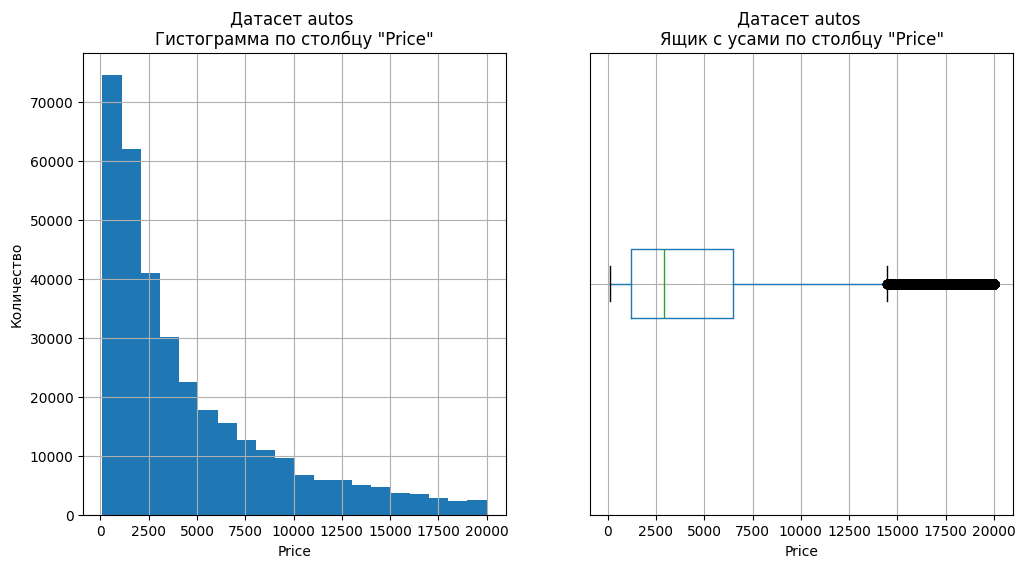

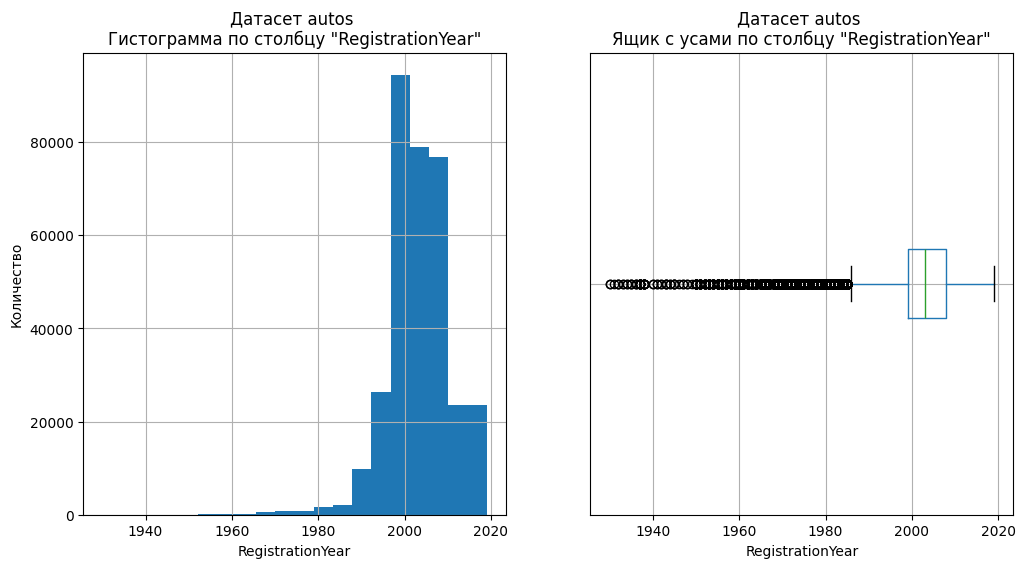

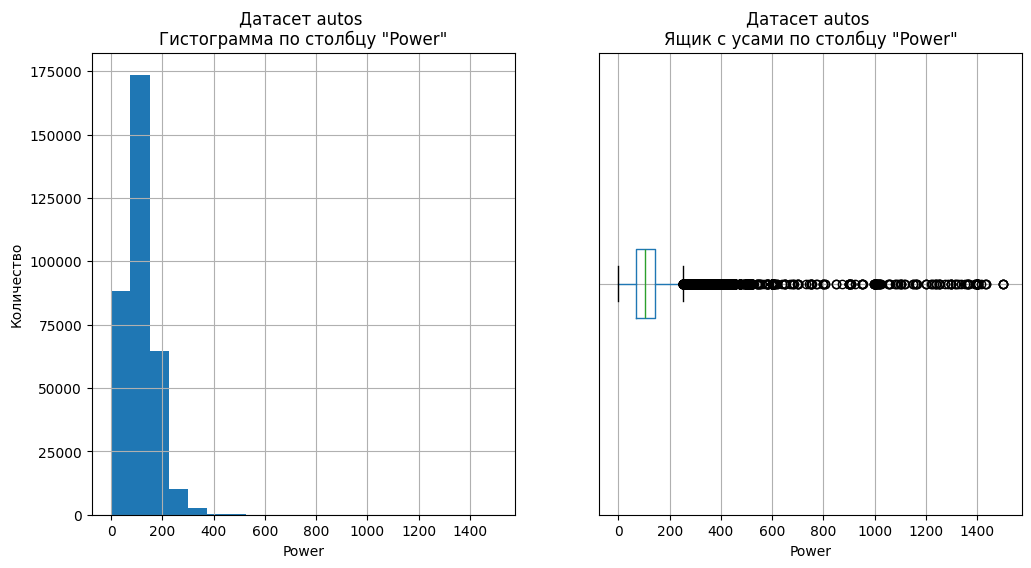

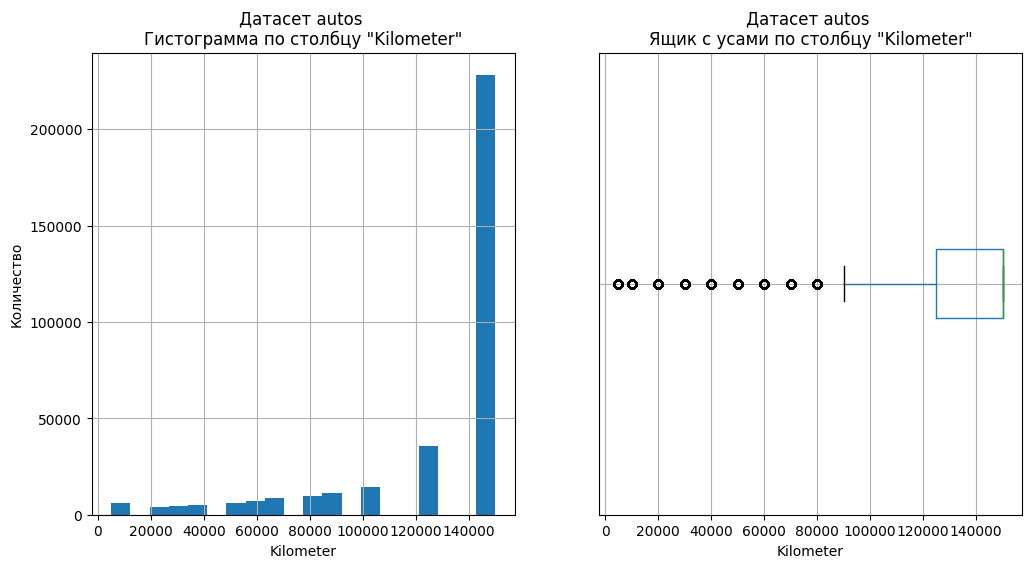

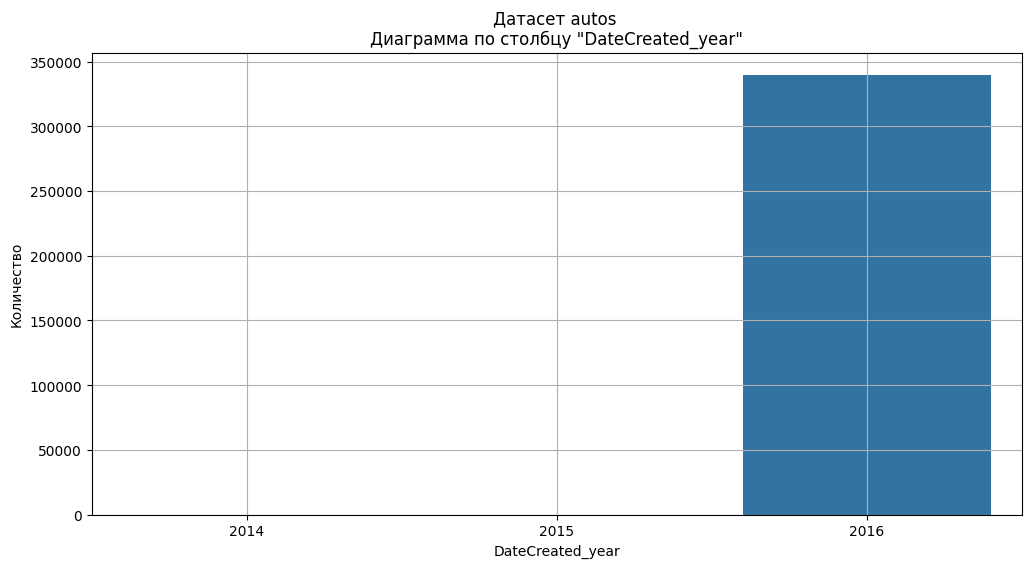

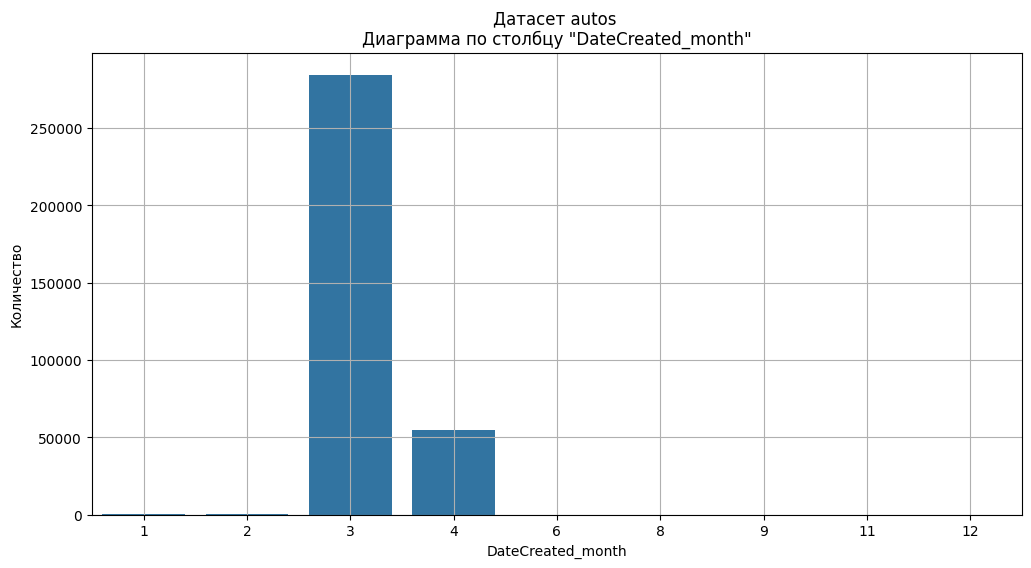

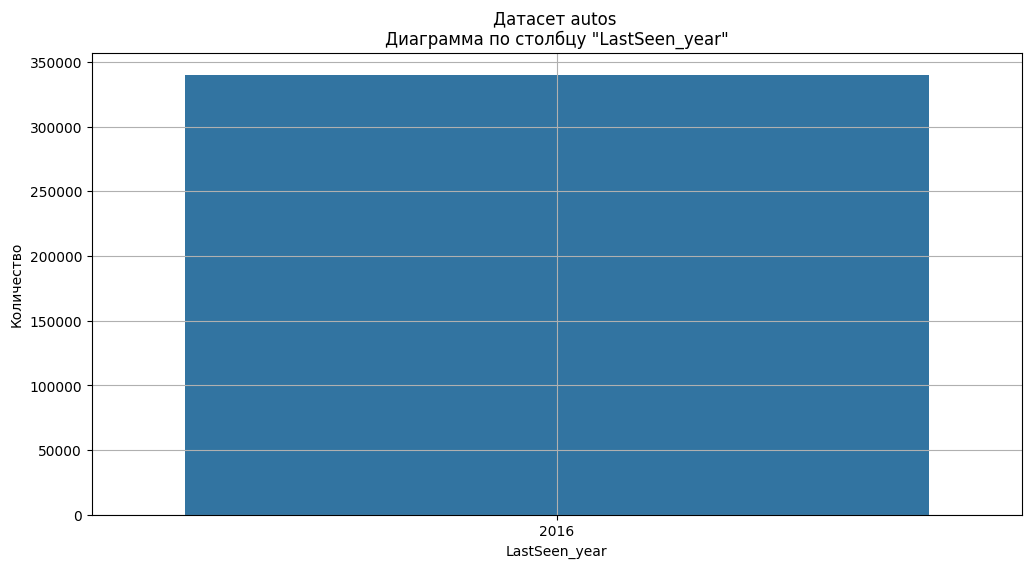

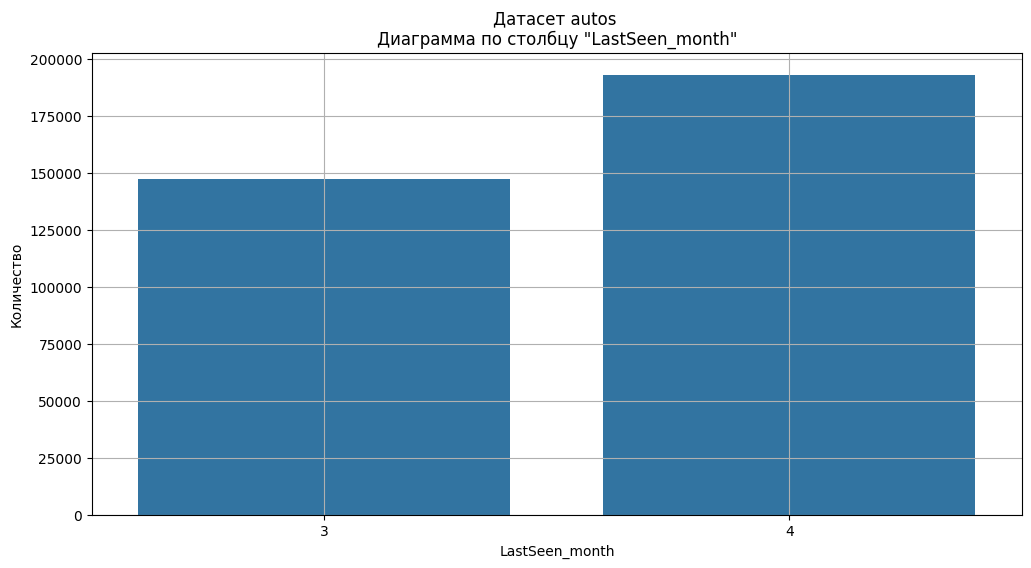

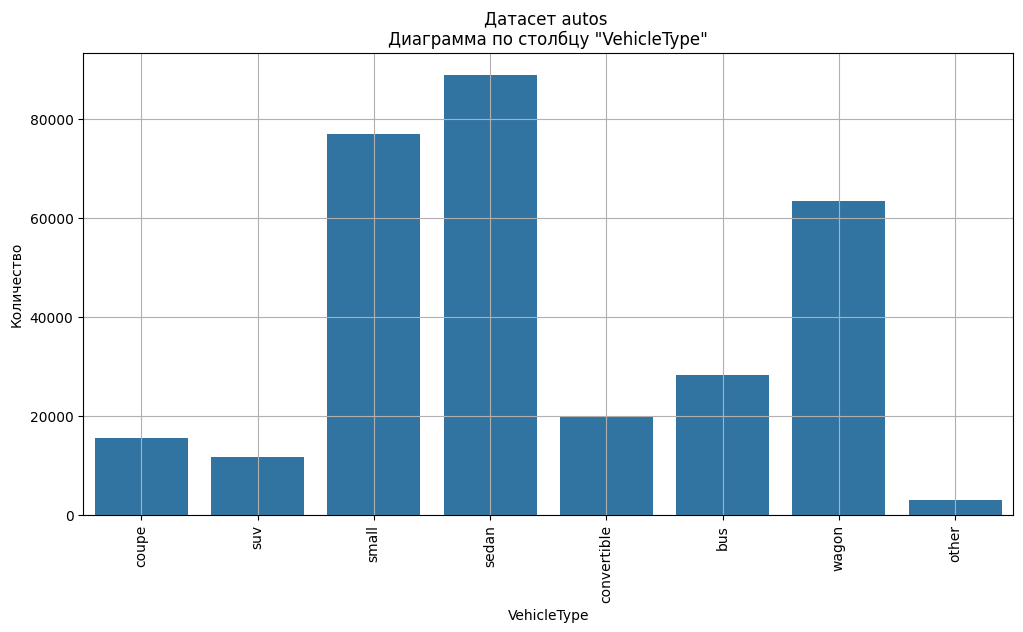

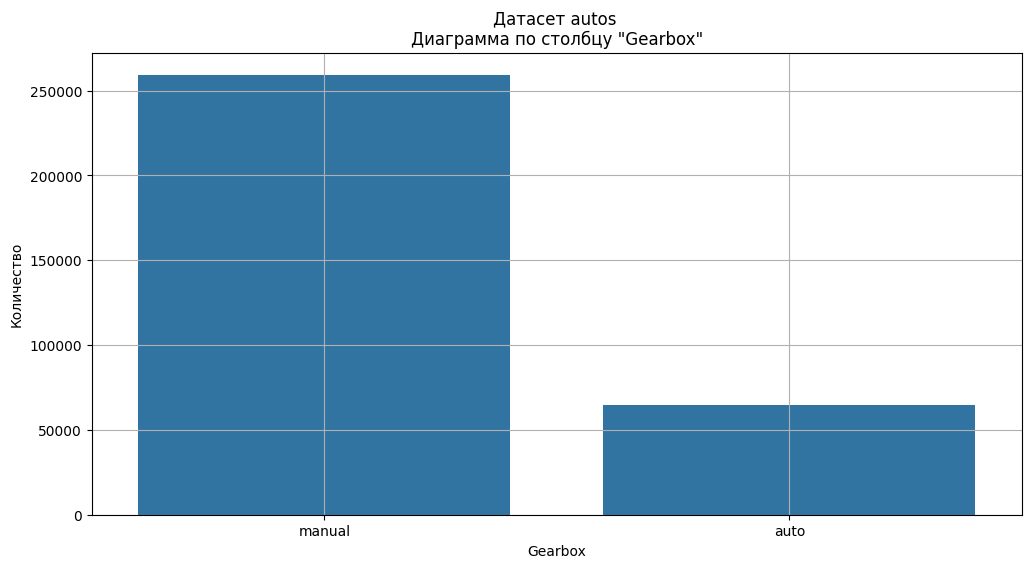

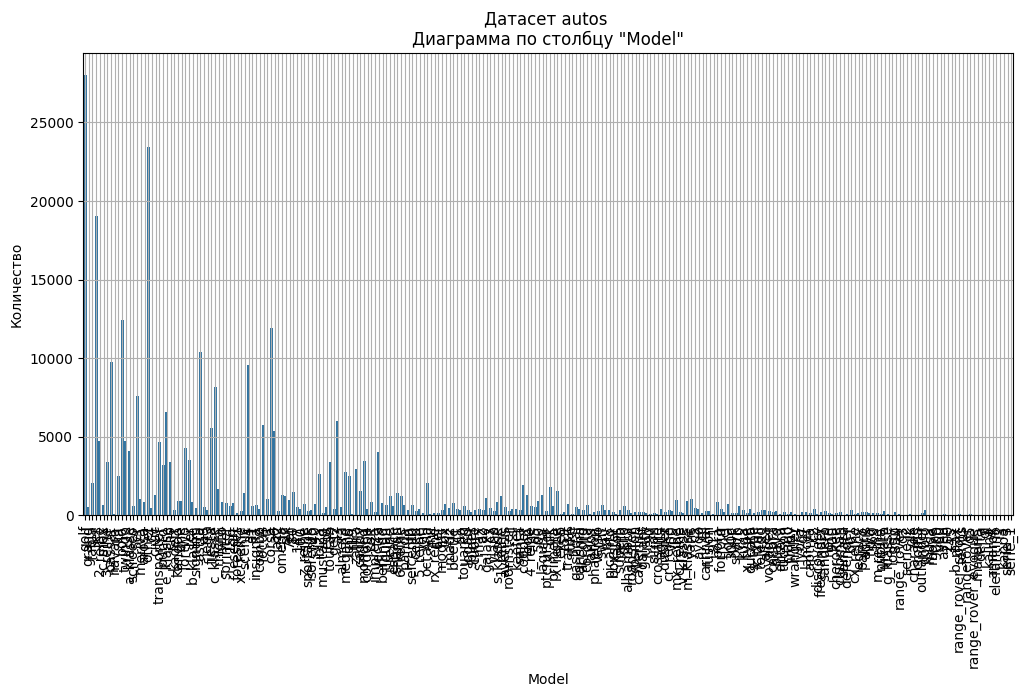

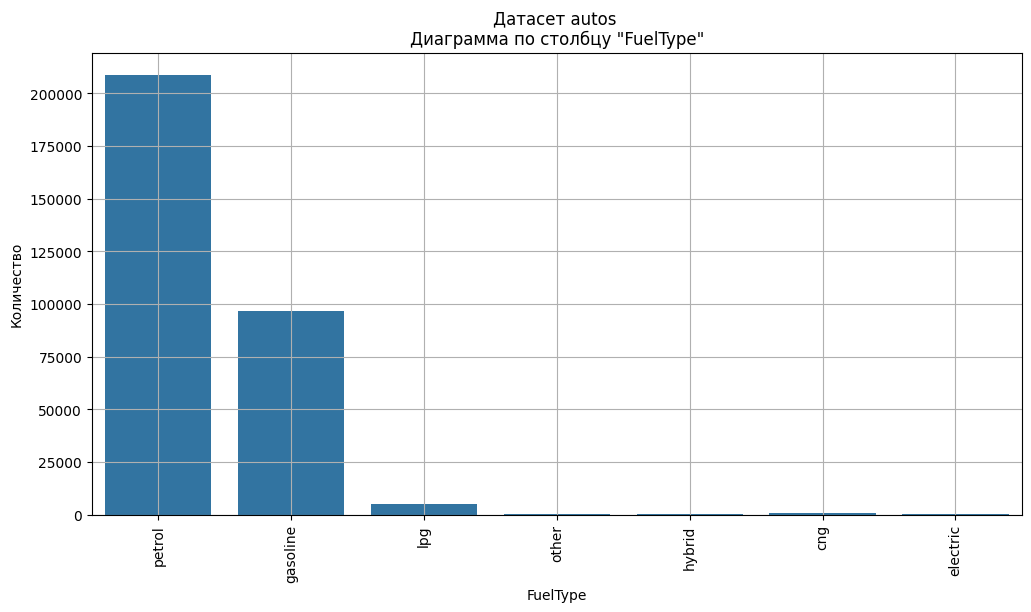

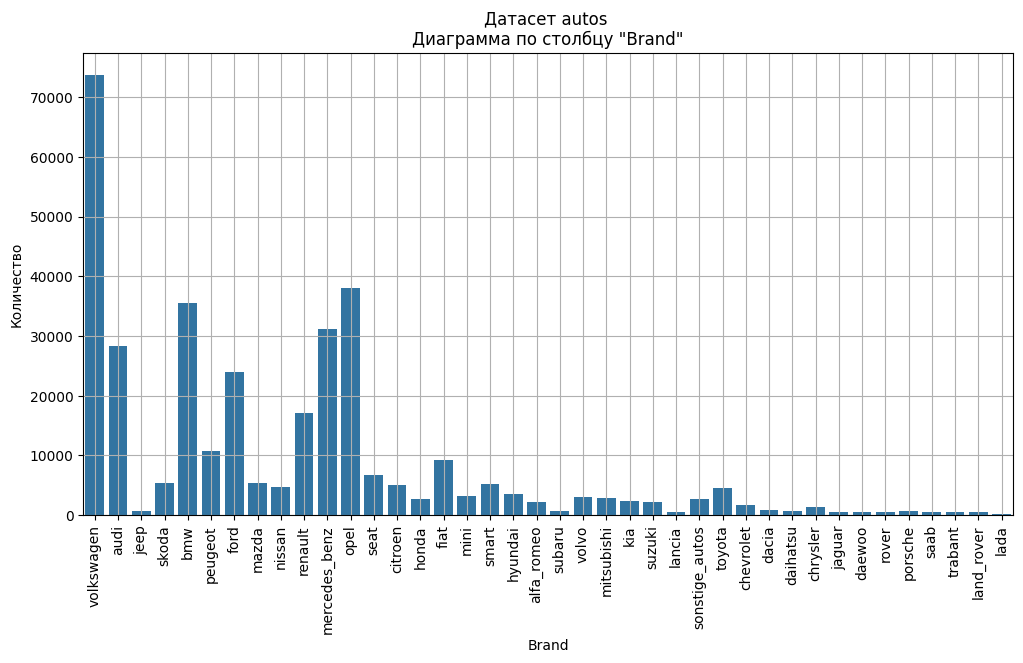

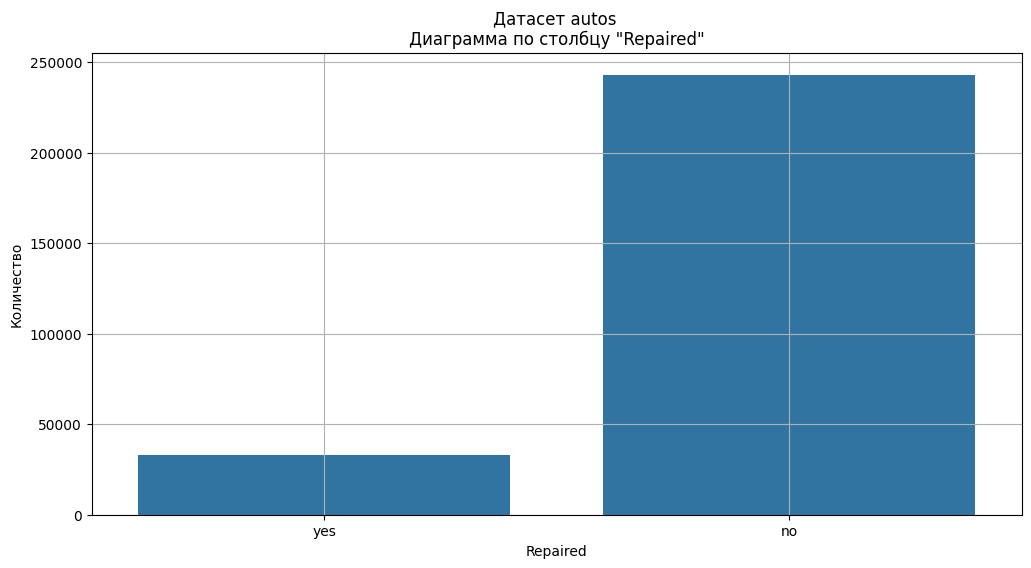

In [27]:
df_hist_dict(dict_1)

### Промежуточный вывод

В результате предобработки и EDA были выполнены следующие шаги:
- RegistrationYear для данных >2026 и <1930 приведены к медианным
- Power при значения больше 1500 приведен к медианным
- Даты разбиты на составляющие год и месяц
- Исключены столбцы PostalCode, Model, RegistrationMonth

## Корреляционный анализ

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable LastSeen_year for analysis 1. Dropping this column
  warnings.warn(


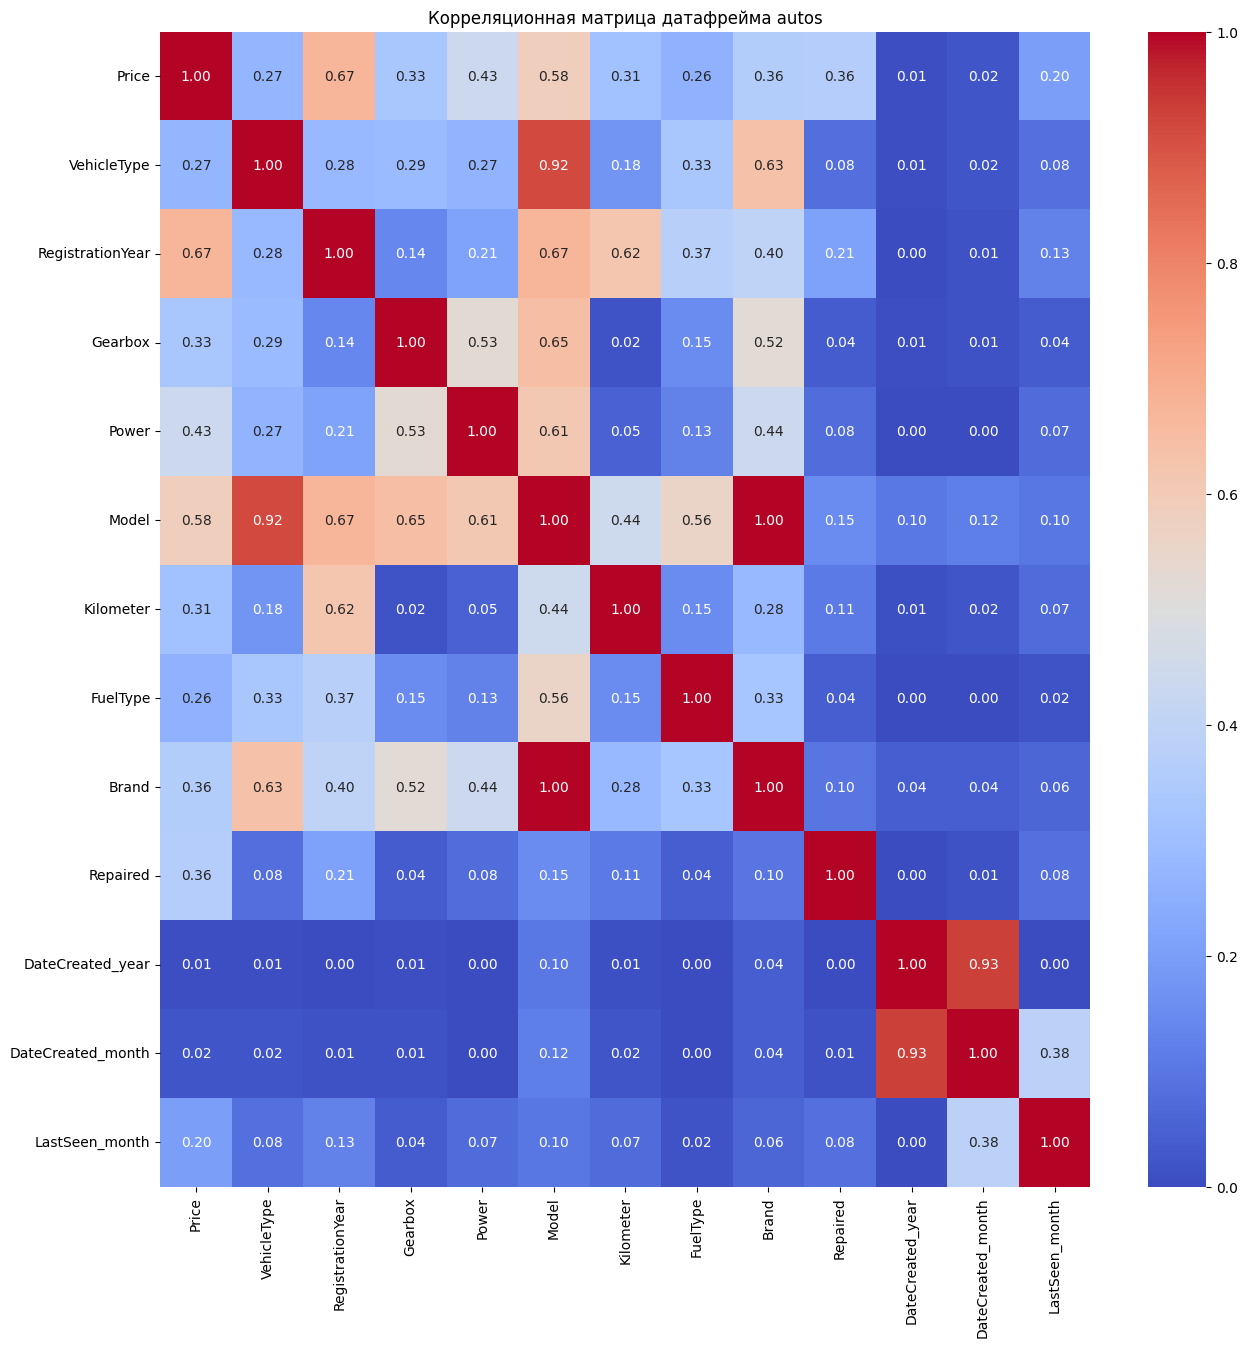

In [28]:
df_corr(dict_1, 
        continuous_features=['Price',
							 'Power',
							 'Kilometer']
                             )

## Подготовка данных

In [29]:
X = dict_1['autos'].drop(columns=['Price'], axis=1)
y = dict_1['autos']['Price']

# разделение на тренировочную и тестовую выборки
X_train_original, X_test_original, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = TEST_SIZE, 
                                                    random_state=RANDOM_STATE
                                                    )

X_train_original.shape, y_train.shape, X_test_original.shape, y_test.shape

((255015, 13), (255015,), (85005, 13), (85005,))

In [30]:
# создаём списки с названиями признаков
cat_columns = X_train_original.select_dtypes('object').columns.tolist()
ohe_columns = ['Repaired'
               ]

bin_columns = ['Brand',
               'FuelType',
               'VehicleType',
               'Gearbox',
               'Model'
               ]

tar_columns = [
    		#    'Model'
               ]
# ord_columns = ['',
#                ]
num_columns = X_train_original.select_dtypes('number').columns.tolist()

In [31]:
# создаём пайплайны для подготовки признаков
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', 
                           handle_unknown='infrequent_if_exist',
                           sparse_output=False 
                           )),
     ('simpleImputer_after_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
    )

num_pipe = Pipeline(
    [('simpleImputer_num', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('standardscaler', StandardScaler())
	]
    )

# SimpleImputer + TargetEncoder
tar_pipe = Pipeline(
    [('simpleImputer_tar', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('tar', TargetEncoder(random_state=RANDOM_STATE
                           )),
     ('simpleImputer_after_tar', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
    )

# SimpleImputer + BinaryEncoder
bin_pipe = Pipeline(
    [('simpleImputer_bin', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('binary', BinaryEncoder(drop_invariant=True, 
                              )),
     ('simpleImputer_after_bin', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
    )

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
# ord_pipe = Pipeline(
#     [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
#      ('ord',  OrdinalEncoder(
#                 categories=[
#                     ['стандарт', 'премиум'],
#                 ], 
#                 handle_unknown='use_encoded_value', unknown_value=np.nan
#             )
#      ),
#      ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
#     ]
# )

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', num_pipe, num_columns),
     ('tar', tar_pipe, tar_columns),
	 ('bin', bin_pipe, bin_columns),
    #  ('ord', ord_pipe, ord_columns),
    #  ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)


# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    # ('poly_features', PolynomialFeatures(degree=2, order='C')),
    # ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('models', DecisionTreeRegressor())
])


In [32]:
X_train = data_preprocessor.fit_transform(X_train_original, y_train)
X_test = data_preprocessor.transform(X_test_original)

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\base.py:411: FutureWarning: The `_get_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


### Промежуточный вывод
Данные для обучения и тестирования моделей подготовлены. Все пропуски заполняются в Pipeline

## Обучение моеделей

### LightGBM

In [33]:
model_LGBM = LGBMRegressor(random_state=RANDOM_STATE,
                           num_leaves=40,
                           max_depth=-1,
                           n_estimators=100)

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

%time n_scores = cross_val_score(model_LGBM, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1, error_score='raise')

print('RMSE: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

CPU times: total: 969 ms
Wall time: 1min 23s
RMSE: -1745.828 (18.453)


In [34]:
%time model_LGBM.fit(X_train, y_train)

CPU times: total: 7.47 s
Wall time: 4.05 s


LGBMRegressor(num_leaves=40, random_state=57)

In [35]:
%time model_LGBM.predict(X_test)

c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CPU times: total: 969 ms
Wall time: 277 ms


array([11800.65184451, 11650.44379244,   808.09910641, ...,
        1104.92321569,   566.72129586,  5373.18911895])

### LinearRegression

In [36]:
model_LR = LinearRegression()

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
%time n_scores = cross_val_score(model_LR, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1, error_score='raise')

print('RMSE: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

CPU times: total: 1.11 s
Wall time: 12.8 s
RMSE: -3062.431 (27.492)


In [37]:
%time model_LR.fit(X_train, y_train)

CPU times: total: 1.17 s
Wall time: 617 ms


LinearRegression()

In [38]:
%time model_LR.predict(X_test)

CPU times: total: 15.6 ms
Wall time: 11 ms


array([7515.90375246, 8349.76127336,  721.96636278, ...,  -23.02587648,
       -792.32535523, 5897.15115099])

### KNeighborsRegressor

In [39]:
model_K = KNeighborsRegressor(n_neighbors=5,
                              n_jobs=-1)

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
%time n_scores = cross_val_score(model_K, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1, error_score='raise')

print('RMSE: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

CPU times: total: 1.08 s
Wall time: 8min 3s
RMSE: -1931.711 (19.772)


In [40]:
%time model_K.fit(X_train, y_train)

CPU times: total: 93.8 ms
Wall time: 186 ms


KNeighborsRegressor(n_jobs=-1)

In [41]:
%time model_K.predict(X_test)

CPU times: total: 4min 59s
Wall time: 1min 19s


array([10659.8,  9251. ,  1008. , ...,   910. ,   380. ,  5919.4])

### Анализ метрик

Согласно заданию заказчика необходимо выбирать модель с лучшими значениями RMSE, при этом RMSE не должно быть больше 2500.

Согласно результатам кроссвалидации показаны результаты:
- LightGBM 
	- RMSE = 1785
	- Время обучения 7,5 сек.
	- Время предсказания 1 сек
- LinearRegression 
	- RMSE = 3062
	- Время обучения 1.11 сек.
	- Время предсказания 1.17 сек
- KNN 
	- RMSE = 1931
	- Время обучения 0,1 сек.
	- Время предсказания 4 мин 59 сек

Лучшая модель по кроссвалидации LightGBM

### Тестирование лучшей модели

In [56]:
%%time
model = model_LGBM

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Лучшая модель RMSE: %.3f' % (root_mean_squared_error(y_test, pred)))

Лучшая модель RMSE: 1749.896
CPU times: total: 6.48 s
Wall time: 2.1 s


c:\Users\navoh\.conda\envs\practicum\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Важность признаков

In [61]:
# Получение важности
feature_importance = model.feature_importances_
features = pipe_final.named_steps['preprocessor'].get_feature_names_out()

In [62]:
# Сортировка и выбор топ-N признаков
importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(10)  # топ-10

C:\Users\navoh\AppData\Local\Temp\ipykernel_22004\3556914818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y='feature', x='importance', palette='viridis')


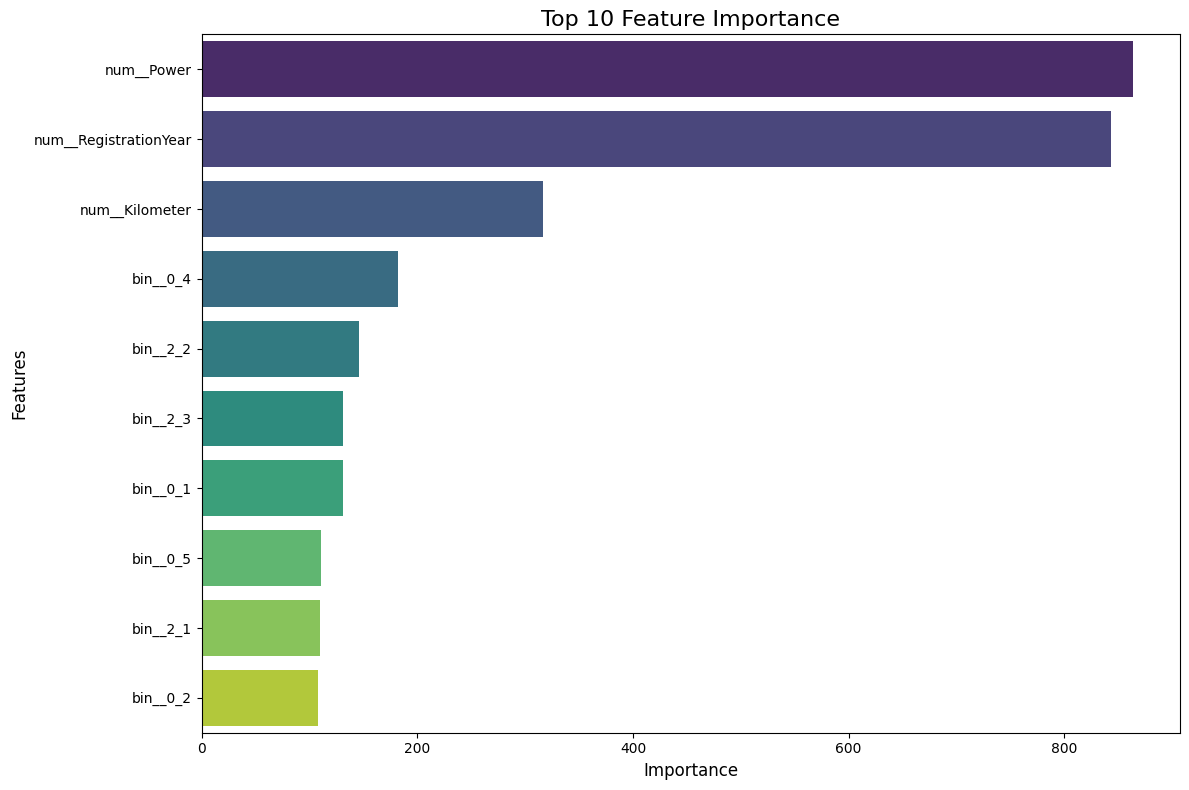

In [63]:
# Построение графика
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, y='feature', x='importance', palette='viridis')
plt.title('Top 10 Feature Importance', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## Вывод

Были изучены полученные данные. Аномалии по мощности автомобилей приведены к медианным значениям.

Подготовлены выборки для обучения и тестирования моделей с помощью Pipeline.

Обучены 3 модели:
- LightGBM 
	- RMSE = 1785
	- Время обучения 7,5 сек.
	- Время предсказания 1 сек
- LinearRegression 
	- RMSE = 3062
	- Время обучения 1.11 сек.
	- Время предсказания 1.17 сек
- KNeighborsRegressor 
	- RMSE = 1931
	- Время обучения 0,1 сек.
	- Время предсказания 4 мин 59 сек
 
В качестве итоговой модели была выбрана модель LightGBM с метрикой RMSE на тестовой выборке 1785.
